# Clasificación de animales (perro, gato, pájaro) con CNN

En este notebook se entrena y evalúa un modelo de red neuronal convolucional (CNN)
para clasificar imágenes en tres clases: **perro**, **gato** y **pájaro**.

El dataset ya fue preparado previamente en `00_preparar_animalitos.ipynb` y se
encuentra organizado en la estructura:

../data/animales/
  train/perro, gato, pajaro
  val/perro,   gato, pajaro
  test/perro,  gato, pajaro


In [ ]:
# Celda 2: Imports y configuración general

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Se fuerza a TensorFlow a ejecutar todas las funciones en modo eager.
# Esto evita el error "numpy() is only available when eager execution is enabled".
tf.config.run_functions_eagerly(True)

print("Versión de TensorFlow:", tf.__version__)
print("Eager execution activo:", tf.executing_eagerly())


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, losses

from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# Fijación de semillas para reproducibilidad.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Se asume que el notebook está en la carpeta 'notebooks'.
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data" / "animales"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"
TEST_DIR  = DATA_DIR / "test"

# Parámetros de las imágenes.
IMG_HEIGHT = 128
IMG_WIDTH  = 128
BATCH_SIZE = 32

print("TensorFlow version:", tf.__version__)
print("BASE_DIR :", BASE_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("TEST_DIR :", TEST_DIR)


Versión de TensorFlow: 2.20.0
Eager execution activo: True
TensorFlow version: 2.20.0
BASE_DIR : C:\Users\DANIELA\Documents\proyecto_final_procesamiento
TRAIN_DIR: C:\Users\DANIELA\Documents\proyecto_final_procesamiento\data\animales\train
VAL_DIR  : C:\Users\DANIELA\Documents\proyecto_final_procesamiento\data\animales\val
TEST_DIR : C:\Users\DANIELA\Documents\proyecto_final_procesamiento\data\animales\test


In [2]:
# Celda 3: Conteo de imágenes por clase en cada partición

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp"]

def count_images_in_dir(split_dir: Path):
    """
    Cuenta el número de imágenes en cada subcarpeta de clases dentro de 'split_dir'.
    """
    counts = {}
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            n_imgs = 0
            for ext in IMAGE_EXTENSIONS:
                n_imgs += len(list(class_dir.glob(f"*{ext}")))
            counts[class_dir.name] = n_imgs
    return counts

print("=== Conteo de imágenes por clase ===")
print("Train:", count_images_in_dir(TRAIN_DIR))
print("Val  :", count_images_in_dir(VAL_DIR))
print("Test :", count_images_in_dir(TEST_DIR))


=== Conteo de imágenes por clase ===
Train: {'gato': 3507, 'pajaro': 3507, 'perro': 3507}
Val  : {'gato': 751, 'pajaro': 751, 'perro': 751}
Test : {'gato': 753, 'pajaro': 753, 'perro': 753}


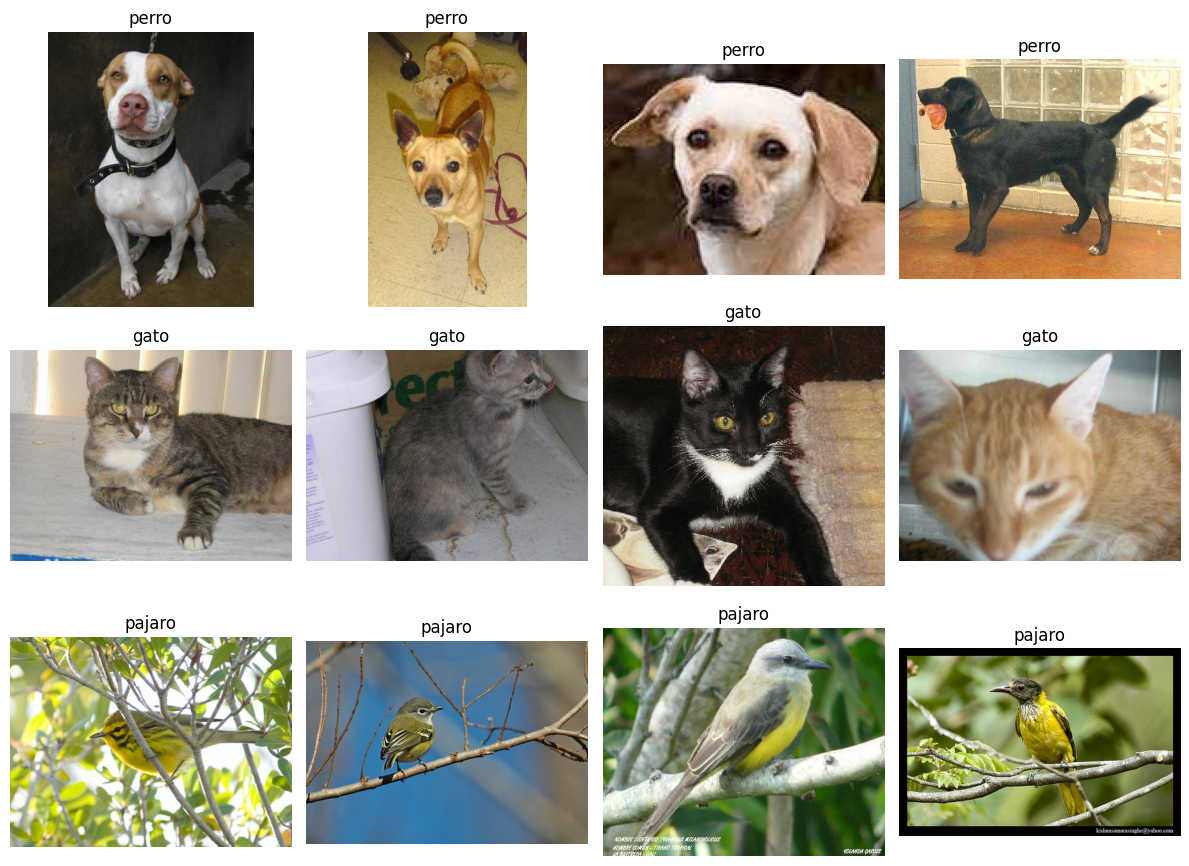

In [3]:
# Celda 4: Visualización de ejemplos de imágenes por clase

import random
from PIL import Image

CLASSES = ["perro", "gato", "pajaro"]  # nombres de carpetas de clase

def show_examples_per_class(split_dir: Path, classes, n_per_class=4):
    """
    Muestra algunas imágenes de ejemplo por clase, tomadas del directorio indicado.
    """
    plt.figure(figsize=(n_per_class * 3, len(classes) * 3))
    
    idx = 1
    for cls in classes:
        class_path = split_dir / cls
        img_paths = []
        for ext in IMAGE_EXTENSIONS:
            img_paths.extend(class_path.glob(f"*{ext}"))
        if len(img_paths) == 0:
            print(f"[ADVERTENCIA] No se encontraron imágenes para la clase '{cls}' en {class_path}")
            continue
        
        sample_paths = random.sample(img_paths, min(n_per_class, len(img_paths)))
        
        for p in sample_paths:
            plt.subplot(len(classes), n_per_class, idx)
            img = Image.open(p).convert("RGB")
            plt.imshow(img)
            plt.axis("off")
            plt.title(cls)
            idx += 1
    
    plt.tight_layout()
    plt.show()

# Se muestran ejemplos del conjunto de entrenamiento.
show_examples_per_class(TRAIN_DIR, CLASSES, n_per_class=4)


In [4]:
# Celda 5: Definición de generadores con data augmentation

# Generador para entrenamiento con técnicas de aumento de datos.
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,      # normalización al rango [0, 1]
    rotation_range=20,        # rotaciones pequeñas
    width_shift_range=0.1,    # desplazamientos horizontales
    height_shift_range=0.1,   # desplazamientos verticales
    zoom_range=0.1,           # zoom ligero
    horizontal_flip=True,     # espejado horizontal
    fill_mode="nearest"
)

# Generador para validación y prueba, solo con normalización.
test_val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",  # salida one-hot para 3 clases
    shuffle=True,
    seed=SEED
)

val_gen = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("class_indices:", train_gen.class_indices)


Found 10521 images belonging to 3 classes.
Found 2253 images belonging to 3 classes.
Found 2259 images belonging to 3 classes.
class_indices: {'gato': 0, 'pajaro': 1, 'perro': 2}


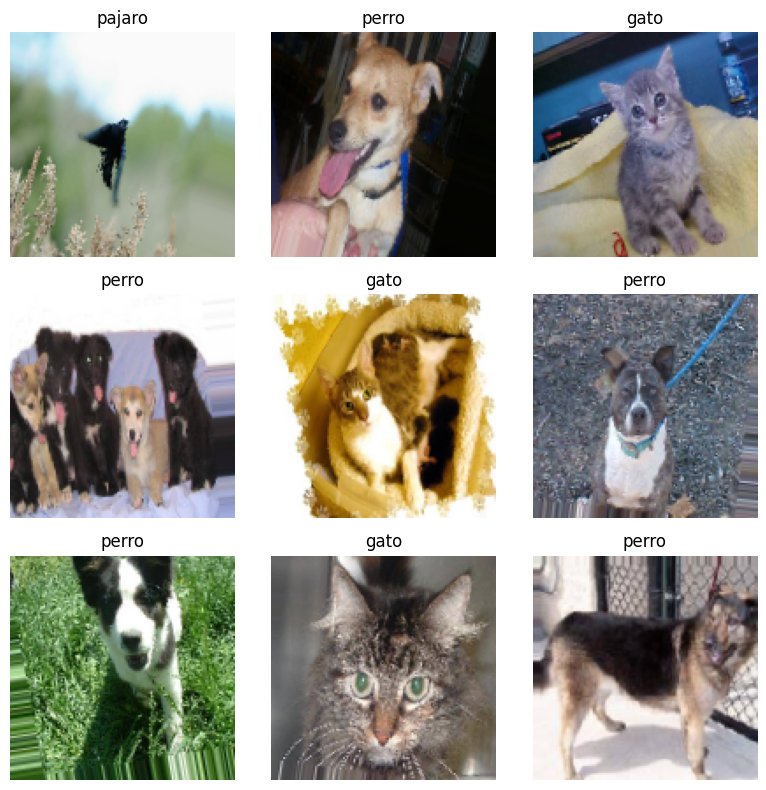

In [5]:
# Celda 6: Visualización de imágenes augmentadas generadas por el generador de entrenamiento

x_batch, y_batch = next(train_gen)  # se toma un batch aleatorio

idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    plt.axis("off")
    label_idx = np.argmax(y_batch[i])
    plt.title(idx_to_class[label_idx])
plt.tight_layout()
plt.show()


In [6]:
# Celda 7: Definición del Modelo 1 (CNN sencilla)

def build_cnn_model_1(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), n_classes=3):
    """
    Define una arquitectura CNN sencilla:
    - Dos bloques convolución + max pooling.
    - Una capa densa intermedia con dropout.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        
        layers.Dense(n_classes, activation="softmax")
    ])
    
    return model

model_1 = build_cnn_model_1(n_classes=train_gen.num_classes)
model_1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,515 (32.08 MB)

 Trainable params: 8,408,515 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Celda 8: Definición del Modelo 2 (CNN más profunda)

def build_cnn_model_2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), n_classes=3):
    """
    Define una arquitectura CNN más profunda:
    - Más filtros y más capas convolucionales.
    - Mayor capacidad de representación.
    - Dropout en la parte densa para reducir sobreajuste.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Bloque 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        # Bloque 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        # Bloque 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation="softmax")
    ])
    
    return model

model_2 = build_cnn_model_2(n_classes=train_gen.num_classes)
model_2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,529,059 (32.54 MB)

 Trainable params: 8,529,059 (32.54 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Celda: Función auxiliar para entrenar modelos y graficar curvas

def train_and_plot(model, optimizer, loss, epochs, train_gen, val_gen, title_prefix="Modelo"):
    """
    Compila y entrena un modelo Keras, y genera las gráficas de pérdida y exactitud
    para entrenamiento y validación.
    Se fuerza la ejecución en modo eager para evitar errores al convertir tensores a numpy().
    """
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"],
        run_eagerly=True  # se fuerza modo eager dentro del modelo
    )
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs
    )
    
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss_hist = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Exactitud
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Acc")
    plt.plot(epochs_range, val_acc, label="Val Acc")
    plt.xlabel("Época")
    plt.ylabel("Exactitud")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()
    
    # Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss_hist, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return history


In [14]:
# Celda 10: Configuraciones de entrenamiento para cada modelo
# Se usan funciones para crear optimizadores nuevos y objetos de pérdida de Keras.
from tensorflow.keras import layers, models, optimizers, losses

configs_model_1 = {
    # Configuración 1A: Adam + CategoricalCrossentropy estándar
    "1A_Adam_CCE": {
        "optimizer_fn": lambda: optimizers.Adam(learning_rate=1e-3),
        "loss": losses.CategoricalCrossentropy()
    },
    # Configuración 1B: SGD + CategoricalCrossentropy estándar
    "1B_SGD_CCE": {
        "optimizer_fn": lambda: optimizers.SGD(learning_rate=1e-2, momentum=0.9),
        "loss": losses.CategoricalCrossentropy()
    }
}

configs_model_2 = {
    # Configuración 2A: Adam LR bajo + CategoricalCrossentropy estándar
    "2A_AdamLowLR_CCE": {
        "optimizer_fn": lambda: optimizers.Adam(learning_rate=5e-4),
        "loss": losses.CategoricalCrossentropy()
    },
    # Configuración 2B: Adam LR bajo + CategoricalCrossentropy con label smoothing
    "2B_AdamLowLR_CCE_LS": {
        "optimizer_fn": lambda: optimizers.Adam(learning_rate=5e-4),
        "loss": losses.CategoricalCrossentropy(label_smoothing=0.1)
    }
}

print("Configs Modelo 1:", list(configs_model_1.keys()))
print("Configs Modelo 2:", list(configs_model_2.keys()))
print("Ejemplo claves dentro de 1A_Adam_CCE:", configs_model_1["1A_Adam_CCE"].keys())


Configs Modelo 1: ['1A_Adam_CCE', '1B_SGD_CCE']
Configs Modelo 2: ['2A_AdamLowLR_CCE', '2B_AdamLowLR_CCE_LS']
Ejemplo claves dentro de 1A_Adam_CCE: dict_keys(['optimizer_fn', 'loss'])



=== Entrenando Modelo 1 - Config 1A_Adam_CCE - 5 épocas ===
Epoch 1/5


c:\Users\DANIELA\Documents\proyecto_final_procesamiento\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


329/329 ━━━━━━━━━━━━━━━━━━━━ 94s 286ms/step - accuracy: 0.5287 - loss: 0.9596 - val_accuracy: 0.6107 - val_loss: 0.8573
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 88s 267ms/step - accuracy: 0.6404 - loss: 0.7705 - val_accuracy: 0.6760 - val_loss: 0.7636
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 88s 267ms/step - accuracy: 0.6720 - loss: 0.7257 - val_accuracy: 0.7040 - val_loss: 0.6716
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 88s 267ms/step - accuracy: 0.6889 - loss: 0.6923 - val_accuracy: 0.7257 - val_loss: 0.6374
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 88s 267ms/step - accuracy: 0.7066 - loss: 0.6605 - val_accuracy: 0.7310 - val_loss: 0.6290


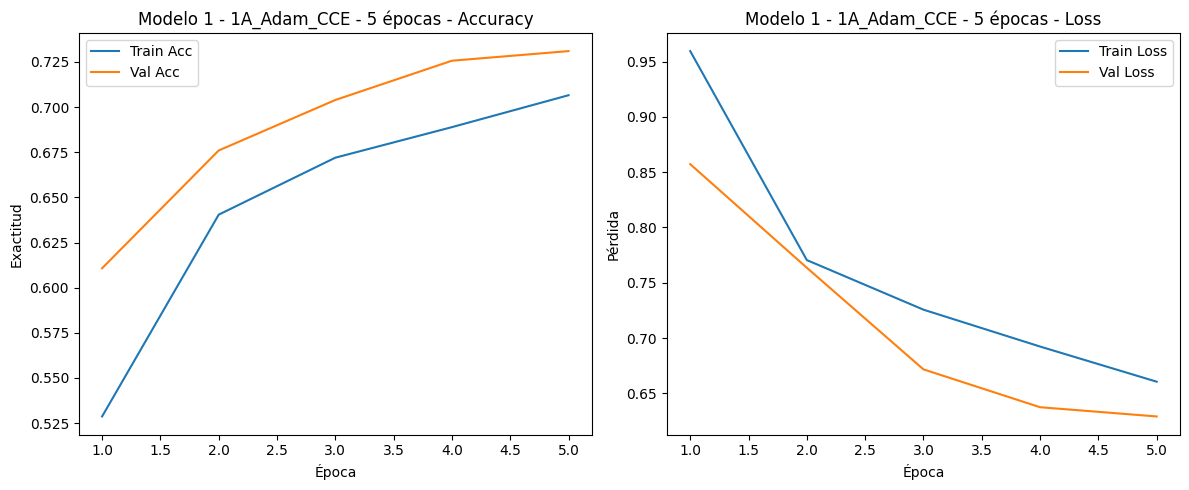


=== Entrenando Modelo 1 - Config 1A_Adam_CCE - 10 épocas ===
Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 88s 268ms/step - accuracy: 0.5367 - loss: 0.9788 - val_accuracy: 0.5775 - val_loss: 0.8667
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 88s 267ms/step - accuracy: 0.6226 - loss: 0.7930 - val_accuracy: 0.6605 - val_loss: 0.7496
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 91s 276ms/step - accuracy: 0.6631 - loss: 0.7370 - val_accuracy: 0.6689 - val_loss: 0.7120
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 93s 282ms/step - accuracy: 0.6741 - loss: 0.7040 - val_accuracy: 0.6662 - val_loss: 0.8271
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 93s 283ms/step - accuracy: 0.6886 - loss: 0.6932 - val_accuracy: 0.6937 - val_loss: 0.7033
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 93s 283ms/step - accuracy: 0.6994 - loss: 0.6602 - val_accuracy: 0.6902 - val_loss: 0.7162
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 93s 283ms/step - accuracy: 0.7015 - loss: 0.6583 - val_accuracy: 0.6822 - val_loss: 0.6943
Epoch 8/10
329/329 ━━

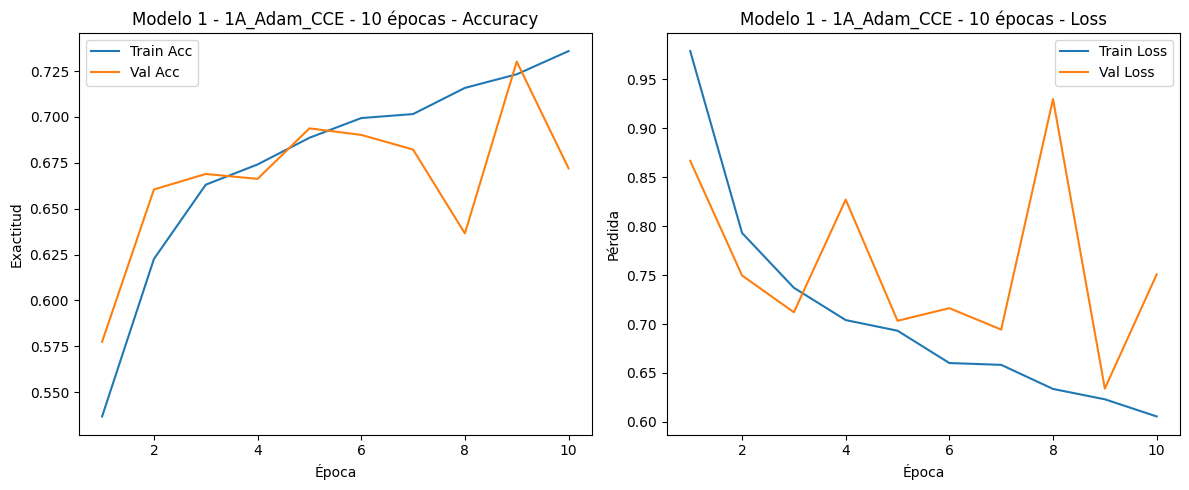


=== Entrenando Modelo 1 - Config 1B_SGD_CCE - 5 épocas ===
Epoch 1/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 79s 239ms/step - accuracy: 0.4590 - loss: 1.0170 - val_accuracy: 0.5362 - val_loss: 0.9359
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 77s 235ms/step - accuracy: 0.5397 - loss: 0.9272 - val_accuracy: 0.6112 - val_loss: 0.8505
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 77s 234ms/step - accuracy: 0.5909 - loss: 0.8526 - val_accuracy: 0.6405 - val_loss: 0.7573
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 79s 241ms/step - accuracy: 0.6035 - loss: 0.8341 - val_accuracy: 0.6298 - val_loss: 0.7583
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 81s 246ms/step - accuracy: 0.6346 - loss: 0.7819 - val_accuracy: 0.6414 - val_loss: 0.7839


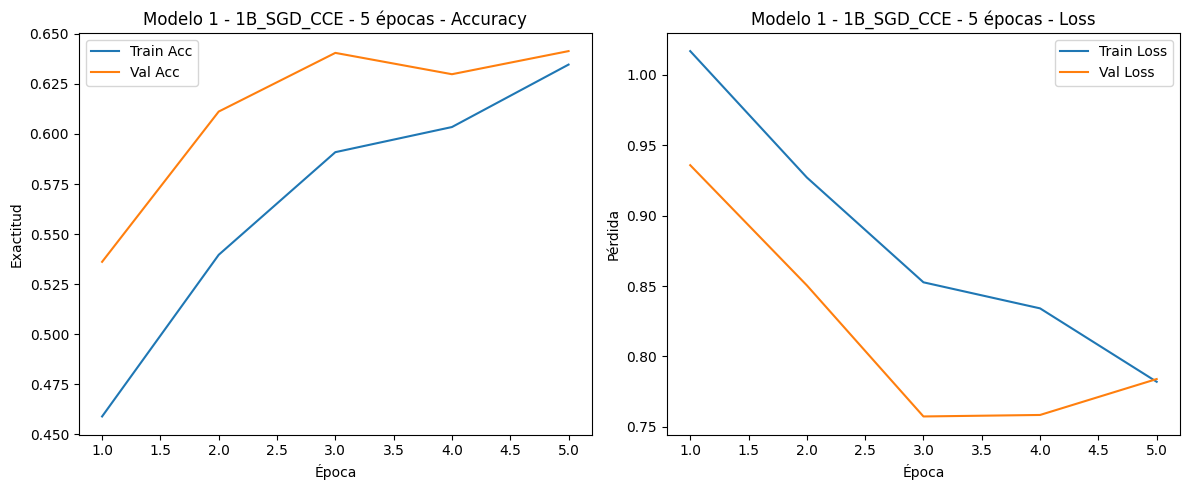


=== Entrenando Modelo 1 - Config 1B_SGD_CCE - 10 épocas ===
Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 79s 238ms/step - accuracy: 0.4418 - loss: 1.0440 - val_accuracy: 0.5388 - val_loss: 0.9114
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 78s 238ms/step - accuracy: 0.5699 - loss: 0.8840 - val_accuracy: 0.6143 - val_loss: 0.8701
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 78s 237ms/step - accuracy: 0.6115 - loss: 0.8151 - val_accuracy: 0.6294 - val_loss: 0.7737
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 78s 238ms/step - accuracy: 0.6222 - loss: 0.7882 - val_accuracy: 0.6258 - val_loss: 0.8051
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 78s 238ms/step - accuracy: 0.6378 - loss: 0.7602 - val_accuracy: 0.6676 - val_loss: 0.7180
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 78s 237ms/step - accuracy: 0.6519 - loss: 0.7373 - val_accuracy: 0.6423 - val_loss: 0.7641
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 78s 237ms/step - accuracy: 0.6698 - loss: 0.7051 - val_accuracy: 0.6707 - val_loss: 0.7163
Epoch 8/10
329/329 ━━━

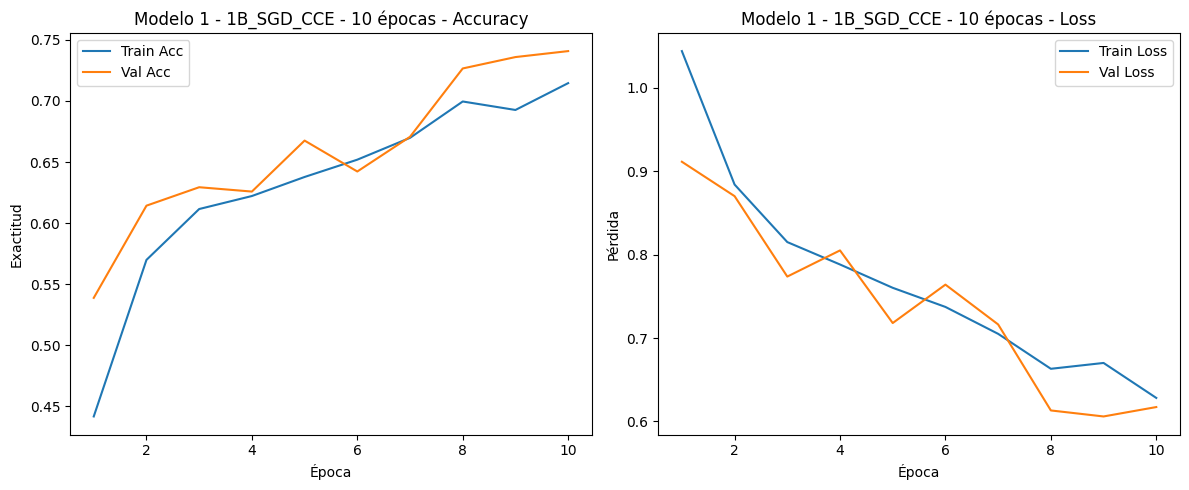


Resumen de mejor val_accuracy para Modelo 1:
1A_Adam_CCE_epochs5: 0.7310
1A_Adam_CCE_epochs10: 0.7301
1B_SGD_CCE_epochs5: 0.6414
1B_SGD_CCE_epochs10: 0.7408


In [10]:
# Celda 11 (NUEVA): Entrenamiento del Modelo 1 con varias configuraciones y números de épocas

EPOCHS_LIST = [5, 10]  # luego puedes ampliar a 5 valores distintos

results_model_1 = {}

for cfg_name, cfg in configs_model_1.items():
    for n_epochs in EPOCHS_LIST:
        print(f"\n=== Entrenando Modelo 1 - Config {cfg_name} - {n_epochs} épocas ===")
        
        # Se crea un modelo NUEVO para cada experimento
        model_1 = build_cnn_model_1(n_classes=train_gen.num_classes)
        # Se crea un optimizador NUEVO para este modelo
        optimizer = cfg["optimizer_fn"]()
        
        history = train_and_plot(
            model_1,
            optimizer=optimizer,
            loss=cfg["loss"],
            epochs=n_epochs,
            train_gen=train_gen,
            val_gen=val_gen,
            title_prefix=f"Modelo 1 - {cfg_name} - {n_epochs} épocas"
        )
        
        best_val_acc = max(history.history["val_accuracy"])
        key = f"{cfg_name}_epochs{n_epochs}"
        results_model_1[key] = {
            "best_val_acc": best_val_acc,
            "history": history
        }

print("\nResumen de mejor val_accuracy para Modelo 1:")
for k, v in results_model_1.items():
    print(f"{k}: {v['best_val_acc']:.4f}")



=== Entrenando Modelo 2 - Config 2A_AdamLowLR_CCE - 5 épocas ===
Epoch 1/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 164s 498ms/step - accuracy: 0.5384 - loss: 0.8987 - val_accuracy: 0.6218 - val_loss: 0.8033
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 160s 486ms/step - accuracy: 0.6406 - loss: 0.7417 - val_accuracy: 0.6622 - val_loss: 0.7617
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 160s 487ms/step - accuracy: 0.6742 - loss: 0.6844 - val_accuracy: 0.7008 - val_loss: 0.6585
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 160s 488ms/step - accuracy: 0.7093 - loss: 0.6378 - val_accuracy: 0.7119 - val_loss: 0.6291
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 160s 487ms/step - accuracy: 0.7430 - loss: 0.5754 - val_accuracy: 0.7403 - val_loss: 0.5941


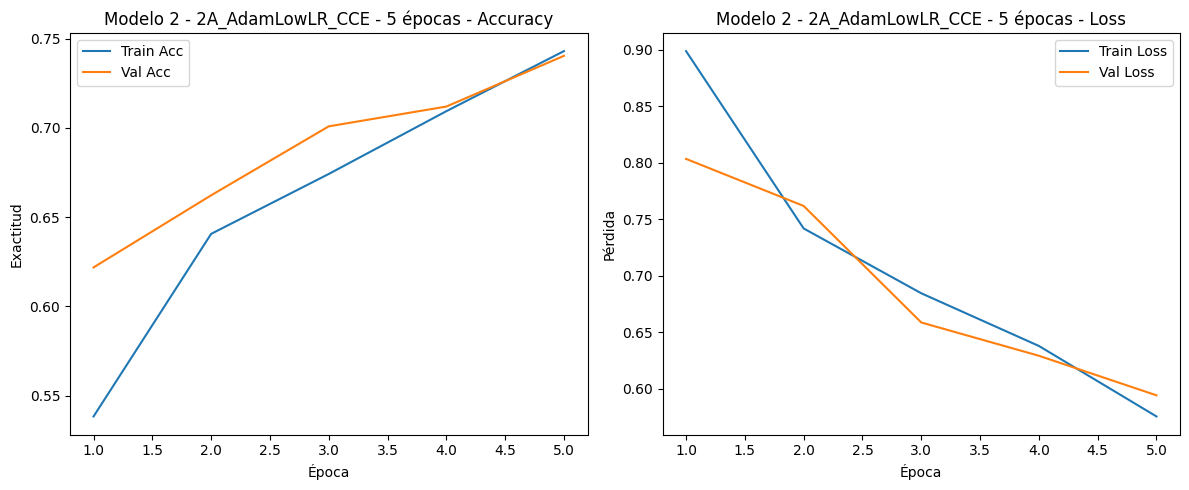


=== Entrenando Modelo 2 - Config 2A_AdamLowLR_CCE - 10 épocas ===
Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 161s 488ms/step - accuracy: 0.5302 - loss: 0.9211 - val_accuracy: 0.6316 - val_loss: 0.7553
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 161s 489ms/step - accuracy: 0.6427 - loss: 0.7455 - val_accuracy: 0.6107 - val_loss: 0.7897
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 161s 489ms/step - accuracy: 0.6970 - loss: 0.6671 - val_accuracy: 0.6702 - val_loss: 0.7023
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 160s 485ms/step - accuracy: 0.7235 - loss: 0.6158 - val_accuracy: 0.6906 - val_loss: 0.7311
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 160s 486ms/step - accuracy: 0.7478 - loss: 0.5665 - val_accuracy: 0.6662 - val_loss: 0.7352
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 518ms/step - accuracy: 0.7660 - loss: 0.5308 - val_accuracy: 0.7679 - val_loss: 0.5353
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 168s 510ms/step - accuracy: 0.7818 - loss: 0.5026 - val_accuracy: 0.7452 - val_loss: 0.6523
Epoch 8/1

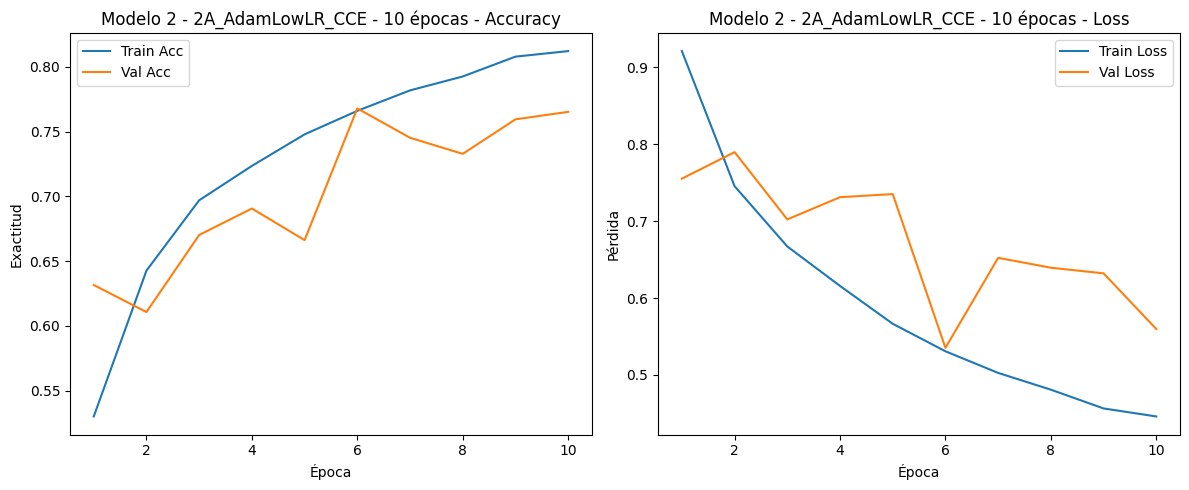


=== Entrenando Modelo 2 - Config 2B_AdamLowLR_CCE_LS - 5 épocas ===
Epoch 1/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 163s 496ms/step - accuracy: 0.5733 - loss: 0.9189 - val_accuracy: 0.6800 - val_loss: 0.8109
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 168s 510ms/step - accuracy: 0.6827 - loss: 0.7942 - val_accuracy: 0.6791 - val_loss: 0.7977
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 172s 522ms/step - accuracy: 0.7224 - loss: 0.7432 - val_accuracy: 0.7501 - val_loss: 0.7088
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 171s 518ms/step - accuracy: 0.7478 - loss: 0.7115 - val_accuracy: 0.7008 - val_loss: 0.7939
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 171s 519ms/step - accuracy: 0.7743 - loss: 0.6813 - val_accuracy: 0.7270 - val_loss: 0.7636


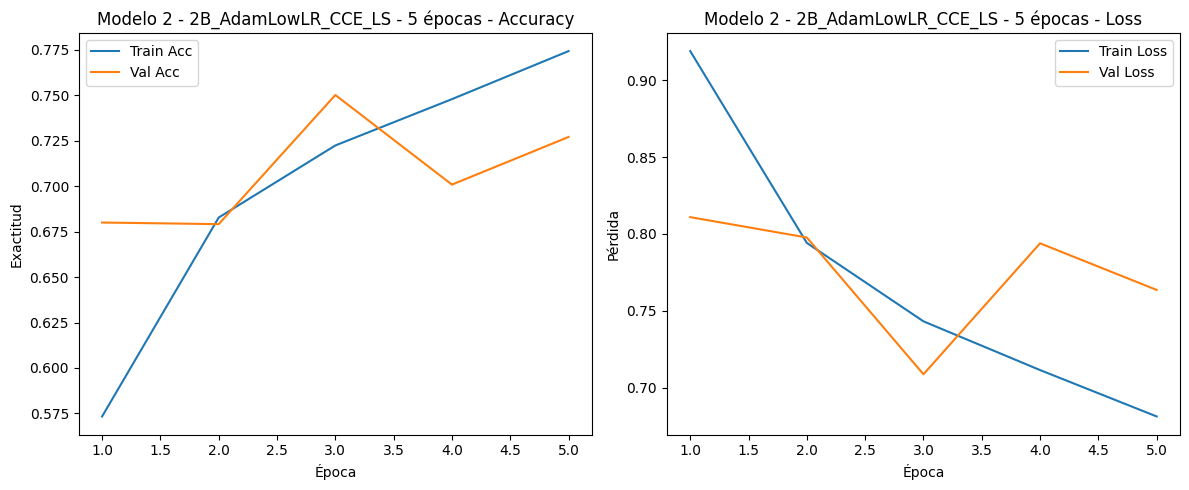


=== Entrenando Modelo 2 - Config 2B_AdamLowLR_CCE_LS - 10 épocas ===
Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 517ms/step - accuracy: 0.5392 - loss: 0.9530 - val_accuracy: 0.6116 - val_loss: 0.8709
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 171s 519ms/step - accuracy: 0.6464 - loss: 0.8339 - val_accuracy: 0.7084 - val_loss: 0.7556
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 516ms/step - accuracy: 0.6922 - loss: 0.7717 - val_accuracy: 0.7288 - val_loss: 0.7315
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 169s 514ms/step - accuracy: 0.7360 - loss: 0.7211 - val_accuracy: 0.7186 - val_loss: 0.7748
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 515ms/step - accuracy: 0.7672 - loss: 0.6880 - val_accuracy: 0.7128 - val_loss: 0.7728
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 169s 515ms/step - accuracy: 0.7845 - loss: 0.6593 - val_accuracy: 0.7767 - val_loss: 0.6641
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 516ms/step - accuracy: 0.8043 - loss: 0.6340 - val_accuracy: 0.7949 - val_loss: 0.6517
Epoch 

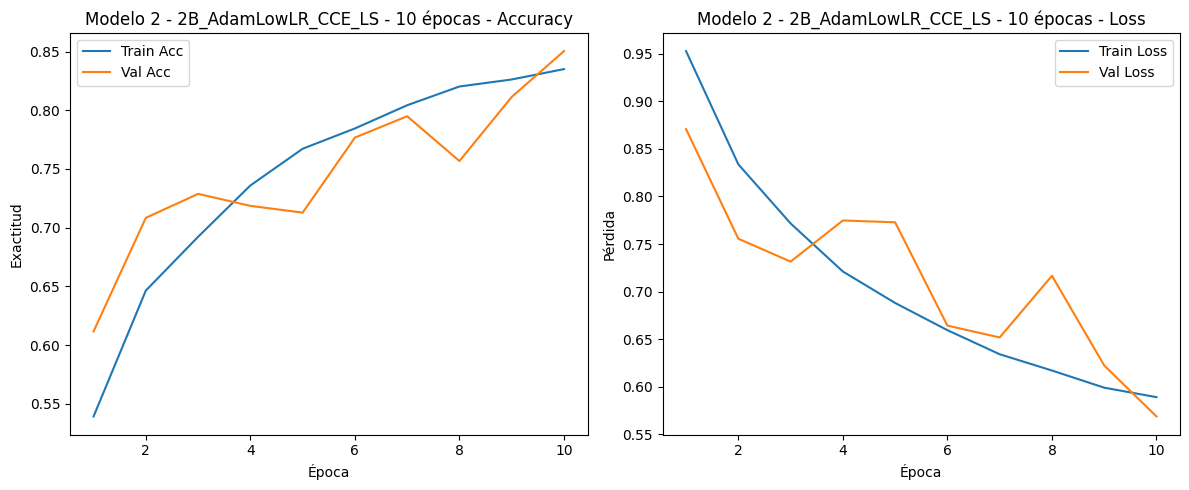


Resumen de mejor val_accuracy para Modelo 2:
2A_AdamLowLR_CCE_epochs5: 0.7403
2A_AdamLowLR_CCE_epochs10: 0.7679
2B_AdamLowLR_CCE_LS_epochs5: 0.7501
2B_AdamLowLR_CCE_LS_epochs10: 0.8504


In [15]:
# Celda 12 : Entrenamiento del Modelo 2 con varias configuraciones y números de épocas

EPOCHS_LIST_2 = [5, 10]

results_model_2 = {}

for cfg_name, cfg in configs_model_2.items():
    for n_epochs in EPOCHS_LIST_2:
        print(f"\n=== Entrenando Modelo 2 - Config {cfg_name} - {n_epochs} épocas ===")
        
        # Modelo NUEVO por experimento
        model_2 = build_cnn_model_2(n_classes=train_gen.num_classes)
        # Optimizador NUEVO por experimento
        optimizer = cfg["optimizer_fn"]()
        
        history = train_and_plot(
            model_2,
            optimizer=optimizer,
            loss=cfg["loss"],
            epochs=n_epochs,
            train_gen=train_gen,
            val_gen=val_gen,
            title_prefix=f"Modelo 2 - {cfg_name} - {n_epochs} épocas"
        )
        
        best_val_acc = max(history.history["val_accuracy"])
        key = f"{cfg_name}_epochs{n_epochs}"
        results_model_2[key] = {
            "best_val_acc": best_val_acc,
            "history": history
        }

print("\nResumen de mejor val_accuracy para Modelo 2:")
for k, v in results_model_2.items():
    print(f"{k}: {v['best_val_acc']:.4f}")


Configuración elegida como modelo final: model_2, 2A_AdamLowLR_CCE, 15 épocas
Epoch 1/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 152s 462ms/step - accuracy: 0.5571 - loss: 0.8859 - val_accuracy: 0.5757 - val_loss: 0.9380
Epoch 2/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 160s 487ms/step - accuracy: 0.6596 - loss: 0.7378 - val_accuracy: 0.6032 - val_loss: 0.9183
Epoch 3/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 515ms/step - accuracy: 0.6954 - loss: 0.6685 - val_accuracy: 0.7155 - val_loss: 0.6259
Epoch 4/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 169s 513ms/step - accuracy: 0.7233 - loss: 0.6178 - val_accuracy: 0.6858 - val_loss: 0.6939
Epoch 5/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 168s 512ms/step - accuracy: 0.7402 - loss: 0.5783 - val_accuracy: 0.6707 - val_loss: 0.7229
Epoch 6/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 166s 505ms/step - accuracy: 0.7661 - loss: 0.5385 - val_accuracy: 0.6644 - val_loss: 0.8115
Epoch 7/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 516ms/step - accuracy: 0.7779 - loss: 0.5143 - val_accuracy: 0.7537 - val_loss: 0.608

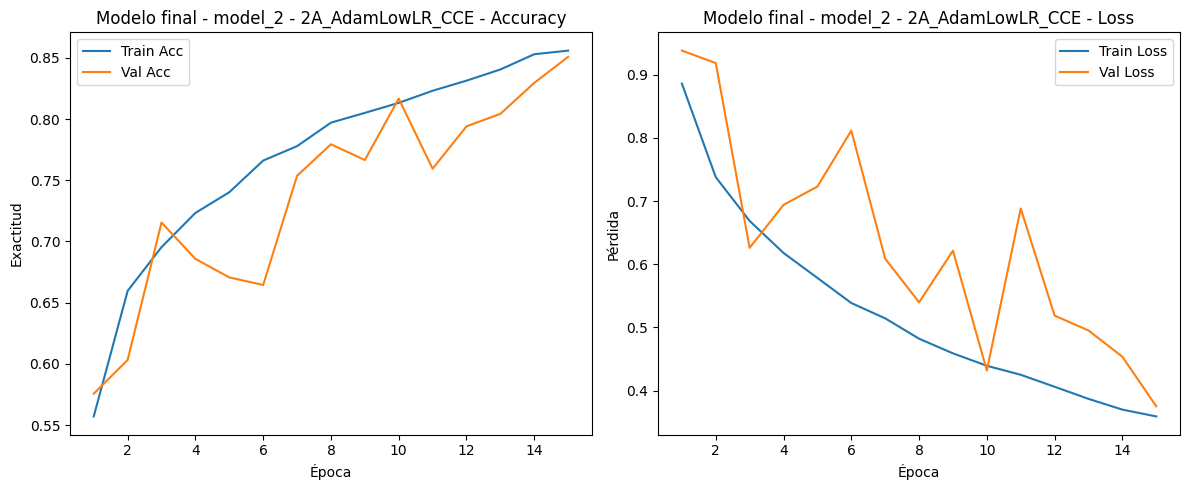

In [17]:
# Celda 13: Selección de la mejor configuración y entrenamiento del modelo final

# Estos valores se eligen manualmente revisando los resultados de las celdas anteriores.
# Se pueden ajustar según los mejores resultados observados.
BEST_MODEL = "model_2"              # "model_1" o "model_2"
BEST_CONFIG_NAME = "2A_AdamLowLR_CCE"  # o "2B_AdamLowLR_CCE_LS"
BEST_EPOCHS = 15                    # número de épocas para el entrenamiento final

print(f"Configuración elegida como modelo final: {BEST_MODEL}, {BEST_CONFIG_NAME}, {BEST_EPOCHS} épocas")

# Se selecciona el constructor de modelo y el diccionario de configuración según el modelo elegido.
if BEST_MODEL == "model_1":
    final_model = build_cnn_model_1(n_classes=train_gen.num_classes)
    best_cfg = configs_model_1[BEST_CONFIG_NAME]
else:
    final_model = build_cnn_model_2(n_classes=train_gen.num_classes)
    best_cfg = configs_model_2[BEST_CONFIG_NAME]

# A partir de la configuración se crea un optimizador NUEVO y se obtiene el objeto de pérdida.
final_optimizer = best_cfg["optimizer_fn"]()
final_loss = best_cfg["loss"]

# Se entrena de nuevo el modelo con la mejor configuración y el número de épocas elegido.
final_history = train_and_plot(
    final_model,
    optimizer=final_optimizer,
    loss=final_loss,
    epochs=BEST_EPOCHS,
    train_gen=train_gen,
    val_gen=val_gen,
    title_prefix=f"Modelo final - {BEST_MODEL} - {BEST_CONFIG_NAME}"
)


71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.8490 - loss: 0.3721
Test Loss: 0.3721
Test Accuracy: 0.8490
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

        gato       0.84      0.77      0.80       753
      pajaro       0.90      0.97      0.93       753
       perro       0.80      0.81      0.81       753

    accuracy                           0.85      2259
   macro avg       0.85      0.85      0.85      2259
weighted avg       0.85      0.85      0.85      2259



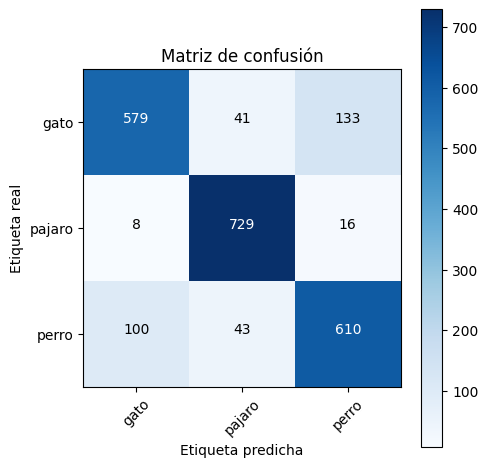

In [18]:
# Celda 14: Evaluación del modelo final en el conjunto de prueba

test_loss, test_acc = final_model.evaluate(test_gen)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Obtención de predicciones para la matriz de confusión.
y_true = test_gen.classes
y_prob = final_model.predict(test_gen)
y_pred = np.argmax(y_prob, axis=1)

# Matriz de confusión y reporte de clasificación.
cm = confusion_matrix(y_true, y_pred)

idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
class_names_ordered = [idx_to_class[i] for i in range(len(idx_to_class))]

print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_names_ordered))

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Matriz de confusión")
plt.colorbar()
tick_marks = np.arange(len(class_names_ordered))
plt.xticks(tick_marks, class_names_ordered, rotation=45)
plt.yticks(tick_marks, class_names_ordered)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("Etiqueta real")
plt.xlabel("Etiqueta predicha")
plt.tight_layout()
plt.show()


In [19]:
# Celda 15: Guardado del modelo final y del orden de las clases

import json

MODELS_DIR = BASE_DIR / "modelos"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "cnn_animales.h5"
final_model.save(model_path)
print(f"Modelo final guardado en: {model_path}")

# Se guarda el orden de las clases tal como lo maneja el generador.
class_indices = train_gen.class_indices  # ej. {'gato': 0, 'perro': 1, 'pajaro': 2}
idx_to_class = {v: k for k, v in class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

class_names_path = MODELS_DIR / "class_names_animales.json"
with open(class_names_path, "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

print(f"Orden de clases guardado en: {class_names_path}")
print("class_names:", class_names)


Modelo final guardado en: C:\Users\DANIELA\Documents\proyecto_final_procesamiento\modelos\cnn_animales.h5
Orden de clases guardado en: C:\Users\DANIELA\Documents\proyecto_final_procesamiento\modelos\class_names_animales.json
class_names: ['gato', 'pajaro', 'perro']


Imagen de prueba: C:\Users\DANIELA\Documents\proyecto_final_procesamiento\data\animales\test\gato\gato_test_00001.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


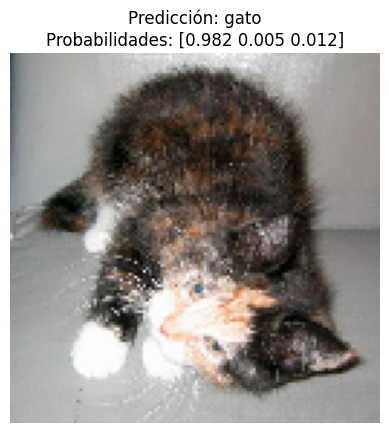

In [26]:
# Celda 16: Prueba de inferencia sobre una imagen de ejemplo

from tensorflow.keras.preprocessing import image

# Se selecciona una clase y se toma una imagen del conjunto de prueba.
example_class = "gato"  # se puede cambiar a "perro" o "pajaro"
example_dir = TEST_DIR / example_class
example_paths = []
for ext in IMAGE_EXTENSIONS:
    example_paths.extend(example_dir.glob(f"*{ext}"))

if len(example_paths) == 0:
    raise RuntimeError(f"No se encontraron imágenes en {example_dir}")

example_path = example_paths[0]
print("Imagen de prueba:", example_path)

# Preprocesamiento compatible con el utilizado en los generadores.
img = image.load_img(example_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # se agrega dimensión de batch

pred_prob = final_model.predict(img_array)[0]
pred_idx = np.argmax(pred_prob)
pred_class = class_names[pred_idx]

plt.imshow(img)
plt.axis("off")
plt.title(f"Predicción: {pred_class}\nProbabilidades: {np.round(pred_prob, 3)}")
plt.show()
